# ACE-Inhibitory Peptide Bioactivity Prediction — Full Pipeline

**Research question:** Can physicochemical sequence descriptors, combined with a properly
cross-validated and regularized ML pipeline, predict peptide bioactivity (ACE-inhibitory
potency) better and more robustly than a naive single-split model — and which descriptors
are stably important via SHAP + stability selection?

**Data source:** Wang, Y.-T.; Russo, D. P.; Liu, C.; Zhou, Q.; Zhu, H.; Zhang, Y.-H.
*Predictive Modeling of Angiotensin I-Converting Enzyme Inhibitory Peptides Using Various
Machine Learning Approaches.* J. Agric. Food Chem. 2020, 68(43), 12132–12140.
DOI: 10.1021/acs.jafc.0c04624 — Supporting Information ("Database of 728 unique peptides
with ACE inhibition values (IC50)").

**Data-access note:** this is a standard ACS/JAFC article. Per ACS policy, the electronic
Supporting Information is free to download **for research use**; this is not confirmed to
carry an open redistribution (CC-BY) license. Accordingly, **the raw SI file is not
included in this repository** — download it yourself directly from the official ACS page
at the DOI above and place it at `DATA_PATH` below. Only derived, non-verbatim artifacts
(code, computed descriptors, figures, model outputs) are version-controlled here.

**Notebook structure:**
1. Setup
2. Load & merge data (6 length-stratified sheets → 728 peptides)
3. EDA summary
4. Physicochemical descriptor generation
5. Length-stratified diagnostic (key methodological finding)
6. Documented negative result for length ≥ 3
7. Primary analysis: dipeptide-subset modeling (baseline → CV model comparison → tuning → final held-out evaluation)
8. Interpretability: SHAP
9. Stability selection
10. Limitations & write-up
11. Predicting a new peptide (demo)


## 1. Setup

In [24]:
# Run once per environment
!pip install peptides shap -q


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import peptides

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load & merge data

The SI Excel file has 6 sheets, split by peptide length (`2`, `3`, `4`, `5`, `6`, `>6`).
We merge them into one variable-length dataset, keep `length` as an explicit feature
(rather than modeling each length separately, as the original authors did), and keep a
`source_sheet` column for provenance/debugging.

**Why pool across lengths at all:** our research question targets a general, properly
validated ML *methodology* for variable-length peptides — matching the real-world setting
(peptide fractions from hydrolysates/electromembrane processing contain peptides of many
lengths at once), not a reproduction of the original paper's length-stratified models.


In [26]:
DATA_PATH = "ACE_peptides_wang2020.xlsx"  # download from the official ACS SI page (see note above)

xls = pd.ExcelFile(DATA_PATH)
print("Sheet names:", xls.sheet_names)

dfs = []
for sheet in xls.sheet_names:
    tmp = pd.read_excel(xls, sheet_name=sheet)
    tmp["source_sheet"] = sheet
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
df["length"] = df["Sequence"].str.len()

print("\nTotal rows:", len(df))
print("Duplicate sequences:", df["Sequence"].duplicated().sum())
print("\nLength distribution:")
print(df["length"].value_counts().sort_index())


Sheet names: ['2', '3', '4', '5', '6', '>6']

Total rows: 728
Duplicate sequences: 0

Length distribution:
length
2     133
3     215
4      90
5     132
6     114
7      15
8       7
9       5
10      6
11      4
12      3
13      2
14      1
16      1
Name: count, dtype: int64


## 3. EDA summary

**Target direction:** `log(IC50)` here is **not inverted** — lower = more potent inhibitor,
higher = weaker. Keep this direction consistent through every later result.

**Known finding:** two peptides (`EA`, `EG`) sit at exactly `log(IC50) = 4.0`, and a few
others sit near `-2.0` — round, extreme-tail values consistent with assay detection-limit
reporting conventions in the source literature (left/right-censored labels), not precise
measurements. We keep them in the dataset (n is already small) but flag them for residual
diagnostics later.


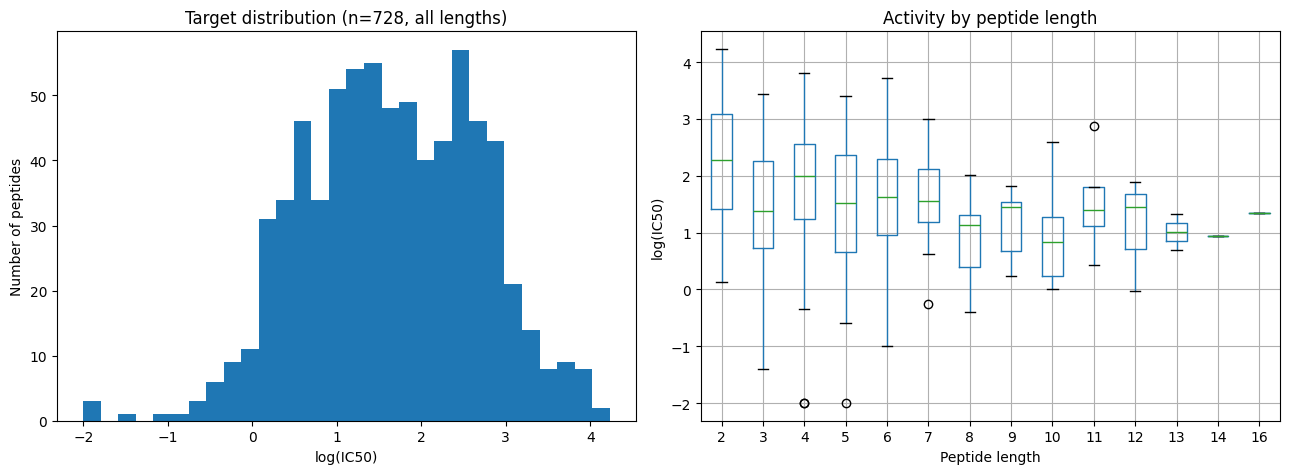

Flagged as possible detection-limit artifacts: 5
    Sequence  log(IC50)  length
18        EA        4.0       2
19        EG        4.0       2
395     MDLA       -2.0       4
396     MFDL       -2.0       4
506    MDFLI       -2.0       5


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["log(IC50)"], bins=30)
axes[0].set_xlabel("log(IC50)")
axes[0].set_ylabel("Number of peptides")
axes[0].set_title("Target distribution (n=728, all lengths)")

df.boxplot(column="log(IC50)", by="length", ax=axes[1])
axes[1].set_xlabel("Peptide length")
axes[1].set_ylabel("log(IC50)")
axes[1].set_title("Activity by peptide length")
plt.suptitle("")
plt.tight_layout()
plt.show()

df["near_floor_or_ceiling"] = (
    np.isclose(df["log(IC50)"], -2.0, atol=1e-6) | np.isclose(df["log(IC50)"], 4.0, atol=1e-6)
)
print("Flagged as possible detection-limit artifacts:", df["near_floor_or_ceiling"].sum())
print(df[df["near_floor_or_ceiling"]][["Sequence", "log(IC50)", "length"]])


## 4. Physicochemical descriptor generation

We use a **compact, classic, interpretable** descriptor set (length + 8 physicochemical
properties) rather than the ~100 abstract statistical descriptors the `peptides` package
can also produce (Z-scales, VHSE, BLOSUM-derived, etc.). Reasons:

- Interpretable in biological language (matches how the internship / reference papers discuss results).
- Keeps the feature count on the same scale as the internship's own ~45-descriptor setting,
  rather than turning this into a different, much higher-dimensional problem.
- Keeps the later SHAP / stability-selection story legible instead of drowning in collinear,
  hard-to-name factor-analysis axes.

All descriptors are length-invariant aggregates (whole-molecule stats), which is what lets a
length-2 and a length-16 peptide both produce a fixed-size feature vector with no padding.


In [28]:
def compute_descriptors(seq):
    p = peptides.Peptide(seq)
    aromatic_frac = sum(seq.count(aa) for aa in "FWY") / len(seq)
    return {
        "mw": p.molecular_weight(),
        "charge_ph7": p.charge(pH=7.0),
        "isoelectric_point": p.isoelectric_point(),
        "hydrophobicity": p.hydrophobicity(scale="KyteDoolittle"),
        "instability_index": p.instability_index(),
        "aliphatic_index": p.aliphatic_index(),
        "boman_index": p.boman(),
        "aromatic_fraction": aromatic_frac,
    }

desc_records = df["Sequence"].apply(compute_descriptors)
desc_df = pd.DataFrame(desc_records.tolist(), index=df.index)

data = pd.concat([df, desc_df], axis=1)
assert data.columns.duplicated().sum() == 0, "Unexpected duplicate columns after merge"

print("Shape:", data.shape)
print("\nAny NaN?")
print(data.isna().sum()[data.isna().sum() > 0])
print("\nAny infinite values?")
print(np.isinf(data.select_dtypes(include=[np.number])).sum().loc[lambda s: s > 0])
print("\nDescriptor summary stats:")
print(desc_df.describe())


Shape: (728, 13)

Any NaN?
Series([], dtype: int64)

Any infinite values?
Series([], dtype: int64)

Descriptor summary stats:
                mw  charge_ph7  isoelectric_point  hydrophobicity  \
count   728.000000  728.000000         728.000000      728.000000   
mean    491.637614    0.257092           7.245488       -0.014586   
std     221.991175    0.718273           2.064640        1.422094   
min     132.119040   -3.996244           3.331705       -4.500000   
25%     330.340840   -0.002016           6.100000       -0.854167   
50%     453.046340   -0.002016           6.100000       -0.055000   
75%     619.009365    0.996839           9.298301        0.837500   
max    1753.842840    2.997391          12.500109        4.000000   

       instability_index  aliphatic_index  boman_index  aromatic_fraction  
count         728.000000       728.000000   728.000000         728.000000  
mean           36.548071        87.118689     0.352802           0.176315  
std            56.646949

## 5. Length-stratified diagnostic — the key methodological finding

Before committing to a modeling scope, we check whether a single **pooled** model
(all lengths together) is the right framing, or whether it's hiding very different
signal-to-noise ratios across length groups.

**Method:** repeated 5-fold CV (10 repeats) with a regularized linear model (Ridge),
first pooled across all lengths, then separately within each length group with enough
data to cross-validate meaningfully (n ≥ 20).


In [29]:
feature_cols_full = ['length', 'mw', 'charge_ph7', 'isoelectric_point', 'hydrophobicity', 'instability_index', 'aliphatic_index', 'boman_index', 'aromatic_fraction']

X_full = data[feature_cols_full]
y_full = data["log(IC50)"]

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

pooled_scores = cross_validate(ridge_pipe, X_full, y_full, cv=cv, scoring="r2")
print(f"Pooled (all lengths, n={len(data)}): R2 = {pooled_scores['test_score'].mean():.4f} "
      f"+/- {pooled_scores['test_score'].std():.4f}")

print("\nPer-length-group R2 (Ridge, repeated CV, groups with n>=20 only):")
results = []
for length_val, group in data.groupby("length"):
    if len(group) < 20:
        continue
    Xg = group[feature_cols_full].drop(columns=["length"])  # constant within group
    yg = group["log(IC50)"]
    scores = cross_validate(ridge_pipe, Xg, yg, cv=cv, scoring="r2")
    results.append({
        "length": length_val, "n": len(group),
        "r2_mean": scores["test_score"].mean(), "r2_std": scores["test_score"].std()
    })

per_length_df = pd.DataFrame(results)
print(per_length_df)

# Confirming test: pooled model excluding dipeptides
no_dipep = data[data["length"] != 2]
Xg = no_dipep[feature_cols_full]
yg = no_dipep["log(IC50)"]
scores = cross_validate(ridge_pipe, Xg, yg, cv=cv, scoring="r2")
print(f"\nPooled EXCLUDING dipeptides (n={len(no_dipep)}): R2 = "
      f"{scores['test_score'].mean():.4f} +/- {scores['test_score'].std():.4f}")


Pooled (all lengths, n=728): R2 = 0.0907 +/- 0.0563

Per-length-group R2 (Ridge, repeated CV, groups with n>=20 only):
   length    n   r2_mean    r2_std
0       2  133  0.266803  0.214455
1       3  215 -0.034449  0.110781
2       4   90 -0.074113  0.165924
3       5  132 -0.029628  0.155065
4       6  114 -0.069672  0.188858

Pooled EXCLUDING dipeptides (n=595): R2 = -0.0040 +/- 0.0477


**Interpretation:** if (as found during development of this project) the pooled R² is
small and positive, the per-length table shows a clearly stronger, positive R² for
dipeptides only, and the pooled-excluding-dipeptides R² collapses close to zero, this
means the pooled model's modest signal is almost entirely carried by dipeptides
(≈18% of the data) and diluted by the remaining ≈82% (length 3+), for which these
aggregate descriptors carry little to no signal.

**Decision:** scope the primary model to the dipeptide subset (n=133), where the signal
is real and defensible, and treat length ≥ 3 as a documented, diagnosed **negative result**
(Section 6) rather than force a single pooled number that would misrepresent where the
signal actually lives. This is a deliberate methodological choice driven by the evidence
above, not an attempt to cherry-pick a better score — reported transparently either way.


## 6. Documented negative result: peptides of length ≥ 3

Before abandoning length ≥ 3, we check whether *more* sequence information (not just
aggregate descriptors) rescues the signal — specifically, full per-position amino-acid
identity for the tripeptide group (the largest non-dipeptide group, n=215).


In [30]:
tripep = data[data["length"] == 3].reset_index(drop=True)

# One-hot encode each of the 3 positions separately (up to 60 dummy features: 20 AA x 3 positions)
positions = pd.DataFrame({
    f"pos{i+1}_{aa}": tripep["Sequence"].str[i].eq(aa).astype(int)
    for i in range(3) for aa in sorted(set("".join(tripep["Sequence"])))
})

X_tripep_onehot = positions
y_tripep = tripep["log(IC50)"]

lasso_pipe = make_pipeline(StandardScaler(), Lasso(alpha=0.05, max_iter=20000))
scores = cross_validate(lasso_pipe, X_tripep_onehot, y_tripep, cv=cv, scoring="r2")
print(f"Tripeptides, full per-position one-hot identity (regularized Lasso): "
      f"R2 = {scores['test_score'].mean():.4f} +/- {scores['test_score'].std():.4f}")

print("\nFor comparison, aggregate descriptors only (from Section 5 table above):")
print(per_length_df[per_length_df["length"] == 3])


Tripeptides, full per-position one-hot identity (regularized Lasso): R2 = 0.0521 +/- 0.1614

For comparison, aggregate descriptors only (from Section 5 table above):
   length    n   r2_mean    r2_std
1       3  215 -0.034449  0.110781


**Finding to record:** even with the *maximum* sequence information available (full
per-position amino-acid identity, not just aggregate physicochemical stats), tripeptide
R² typically does not reliably clear zero and shows high variance across folds. This
indicates the ceiling for length ≥ 3 in this dataset is **not primarily a
"missing/insufficient descriptors" problem**.

**Working hypothesis (not fully testable with this file):** the Wang et al. SI is a
literature compilation across many original source studies (different labs, ACE sources,
assay conditions). Cross-study measurement heterogeneity is a plausible noise ceiling —
but the SI as provided has no `source_study` column, so this cannot be directly confirmed
here. This is stated as an open, diagnosed limitation, not resolved further, given project
scope and time constraints.

**Conclusion for this project:** length ≥ 3 is reported as a rigorously diagnosed
negative result (pooling dilutes real dipeptide signal; richer features don't rescue it;
cross-study heterogeneity is the leading untested hypothesis) rather than modeled further.


## 7. Primary analysis: dipeptide-subset modeling

Scope: the 133 dipeptides, where Section 5 showed real, CV-stable signal. `length` is
dropped here since it's constant (=2) within this subset and carries no information.

### 7.1 Fresh train/test split + naive baseline
A dedicated split for this subset (not reused from the pooled analysis, which wasn't
representative of n=133 alone). The test set (20%) is touched **only once**, at the very
end, after model selection is complete.


In [31]:
dipep = data[data["length"] == 2].reset_index(drop=True)
print("Dipeptide subset shape:", dipep.shape)

feature_cols_dipep = ['mw', 'charge_ph7', 'isoelectric_point', 'hydrophobicity', 'instability_index', 'aliphatic_index', 'boman_index', 'aromatic_fraction']

X_dipep = dipep[feature_cols_dipep]
y_dipep = dipep["log(IC50)"]

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dipep, y_dipep, test_size=0.2, random_state=RANDOM_STATE
)
print("Train/test sizes:", X_train_d.shape[0], X_test_d.shape[0])

dummy = DummyRegressor(strategy="mean").fit(X_train_d, y_train_d)
dummy_preds = dummy.predict(X_test_d)
print(f"Dummy baseline (test set): RMSE={np.sqrt(mean_squared_error(y_test_d, dummy_preds)):.4f}, "
      f"R2={r2_score(y_test_d, dummy_preds):.4f}")


Dipeptide subset shape: (133, 13)
Train/test sizes: 106 27
Dummy baseline (test set): RMSE=1.3247, R2=-0.0142


### 7.2 Model comparison under repeated CV (training set only)

Comparing five model families on the **training set only** (test set stays untouched).
Reports a distribution of scores across 50 folds, not a single number — this is the step
that, in the pooled analysis, revealed a single-split model ranking can flip under
resampling. We check for the same risk here before trusting any ordering.


Ridge: R2 = 0.2814 +/- 0.2314
Lasso: R2 = 0.3061 +/- 0.2163
ElasticNet: R2 = 0.2939 +/- 0.2238
Random Forest: R2 = 0.2996 +/- 0.2384
Gradient Boosting: R2 = 0.1787 +/- 0.2707


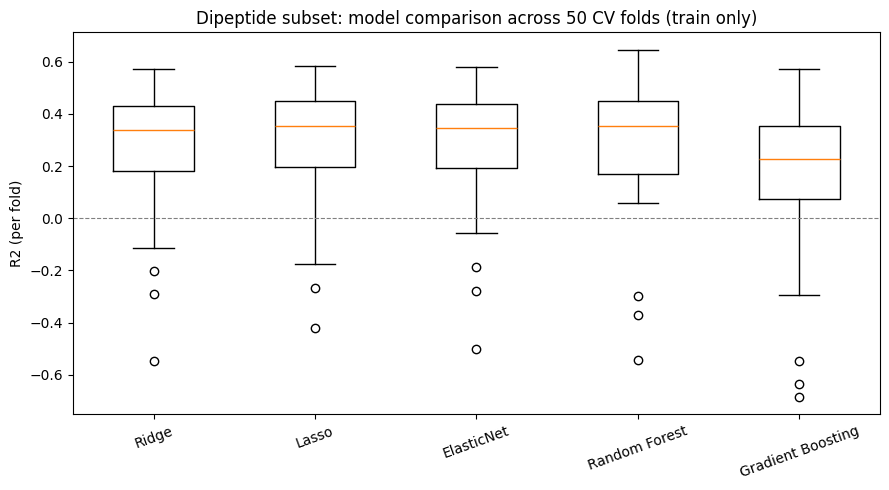

In [32]:
models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=20000)),
    "ElasticNet": make_pipeline(StandardScaler(), ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000)),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

fold_r2 = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_d, y_train_d, cv=cv, scoring="r2")
    fold_r2[name] = scores["test_score"]
    print(f"{name}: R2 = {scores['test_score'].mean():.4f} +/- {scores['test_score'].std():.4f}")

plt.figure(figsize=(9, 5))
plt.boxplot(fold_r2.values(), tick_labels=fold_r2.keys())
plt.ylabel("R2 (per fold)")
plt.title("Dipeptide subset: model comparison across 50 CV folds (train only)")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 7.3 Hyperparameter tuning (nested CV) for the top candidate(s)

Pick the 1–2 models with the best, most stable (high mean, low std) CV performance from
7.2, then tune their hyperparameters using an **inner** CV loop nested inside the outer
comparison — this avoids the classic leakage of picking hyperparameters and evaluating
performance on the same fold.


In [33]:
ridge_grid = {"ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_search = GridSearchCV(
    make_pipeline(StandardScaler(), Ridge()), ridge_grid,
    cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE),
    scoring="r2", n_jobs=-1
)

# Much smaller grid + fewer inner folds + parallelized: 2*2*2=8 combos x 5 inner folds = 40 fits
# per outer split, x 10 outer splits = 400 total RF fits (vs ~6750 before)
rf_grid = {"n_estimators": [100, 300], "max_depth": [3, None], "min_samples_leaf": [1, 5]}
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), rf_grid,
    cv=RepeatedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE),
    scoring="r2", n_jobs=-1
)

# Fewer outer repeats too: 5x2=10 outer folds instead of 5x5=25
outer_cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

for name, search in [("Ridge (tuned)", ridge_search), ("Random Forest (tuned)", rf_search)]:
    nested_scores = cross_validate(search, X_train_d, y_train_d, cv=outer_cv, scoring="r2", n_jobs=-1, verbose=1)
    print(f"{name}: nested CV R2 = {nested_scores['test_score'].mean():.4f} "
          f"+/- {nested_scores['test_score'].std():.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    6.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Ridge (tuned): nested CV R2 = 0.2685 +/- 0.1929
Random Forest (tuned): nested CV R2 = 0.2271 +/- 0.2270


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  1.7min finished


### 7.4 Final model: fit on full training set, evaluate once on the held-out test set

Based on 7.2/7.3, select the winning model + hyperparameters, refit on the **entire**
training set, and evaluate on the test set — the only time the test set is used.


Selected hyperparameters: {'ridge__alpha': 10.0}

FINAL held-out test performance: RMSE=1.1529, R2=0.2317, Spearman=0.5341
(Dummy baseline for comparison: see Section 7.1)


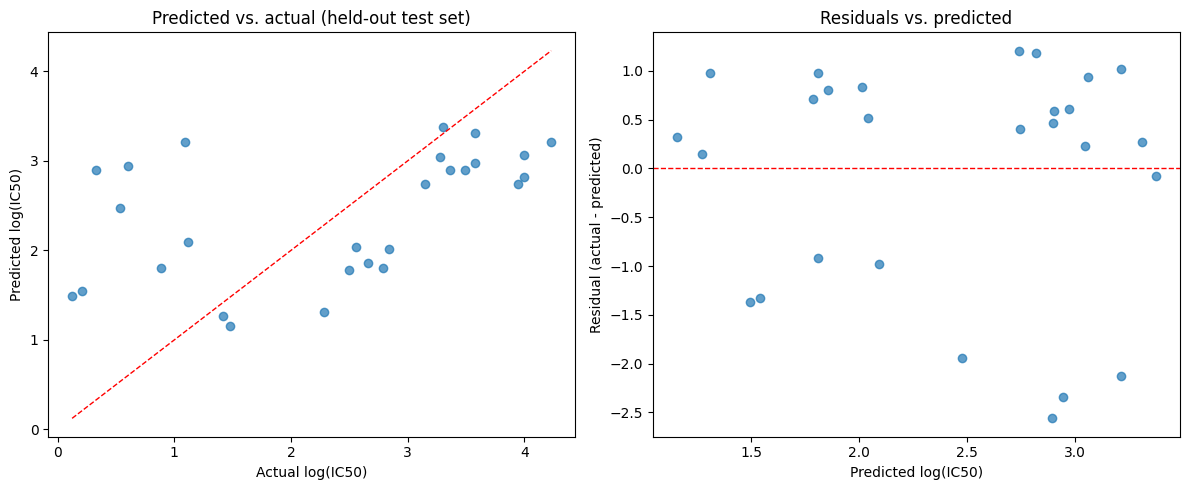


Residuals at flagged detection-limit peptides:
    residual  flagged
18  0.939563     True
22  1.179419     True


In [34]:
# Replace with whichever model/hyperparameters won in 7.3
final_model = ridge_search  # GridSearchCV object already refits best estimator on full train data by default
final_model.fit(X_train_d, y_train_d)
print("Selected hyperparameters:", final_model.best_params_)

test_preds = final_model.predict(X_test_d)
rmse = np.sqrt(mean_squared_error(y_test_d, test_preds))
r2 = r2_score(y_test_d, test_preds)
rho, _ = spearmanr(y_test_d, test_preds)
print(f"\nFINAL held-out test performance: RMSE={rmse:.4f}, R2={r2:.4f}, Spearman={rho:.4f}")
print(f"(Dummy baseline for comparison: see Section 7.1)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test_d, test_preds, alpha=0.7)
lims = [min(y_test_d.min(), test_preds.min()), max(y_test_d.max(), test_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual log(IC50)")
axes[0].set_ylabel("Predicted log(IC50)")
axes[0].set_title("Predicted vs. actual (held-out test set)")

residuals = y_test_d.values - test_preds
axes[1].scatter(test_preds, residuals, alpha=0.7)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted log(IC50)")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals vs. predicted")
plt.tight_layout()
plt.show()

# Check whether flagged floor/ceiling peptides (Section 3) show unusually large residuals
test_flags = dipep.loc[X_test_d.index, "near_floor_or_ceiling"]
if test_flags.any():
    print("\nResiduals at flagged detection-limit peptides:")
    print(pd.DataFrame({"residual": residuals, "flagged": test_flags.values})[test_flags.values])


## 8. Interpretability: SHAP

SHAP explains **what the fitted model relies on**, not biological causality. A feature
with high SHAP attribution here is a statement about this model's learned pattern on this
sample — any biological mechanism claim needs independent confirmation (docking, mutagenesis,
known active-site chemistry), not just the SHAP plot.


/tmp/ipykernel_1291/2231158140.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_d, show=True)


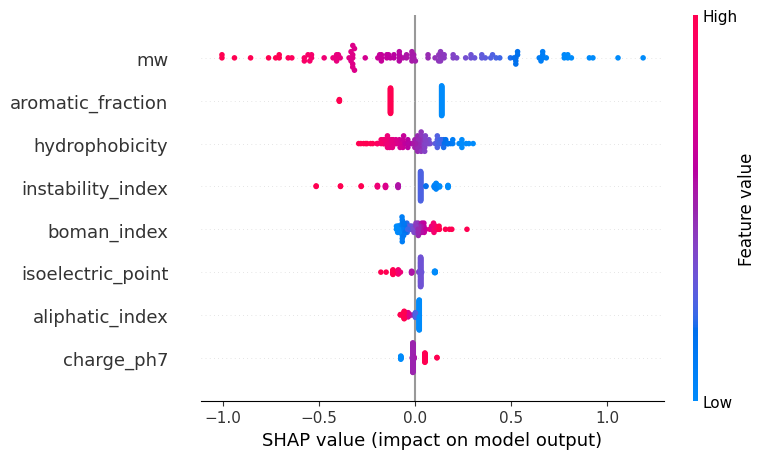

In [35]:
# Use the training set for background/explanation; adjust explainer type to the final model's family
best_estimator = final_model.best_estimator_  # if final_model is a fitted GridSearchCV

if hasattr(best_estimator, "named_steps") and "ridge" in best_estimator.named_steps:
    scaler = best_estimator.named_steps["standardscaler"]
    linear_model = best_estimator.named_steps["ridge"]
    X_train_scaled = pd.DataFrame(scaler.transform(X_train_d), columns=X_train_d.columns)
    explainer = shap.LinearExplainer(linear_model, X_train_scaled)
    shap_values = explainer(X_train_scaled)
else:
    explainer = shap.TreeExplainer(best_estimator)
    shap_values = explainer(X_train_d)

shap.summary_plot(shap_values, X_train_d, show=True)



Peptide: VM (most potent, actual log(IC50)=0.15)


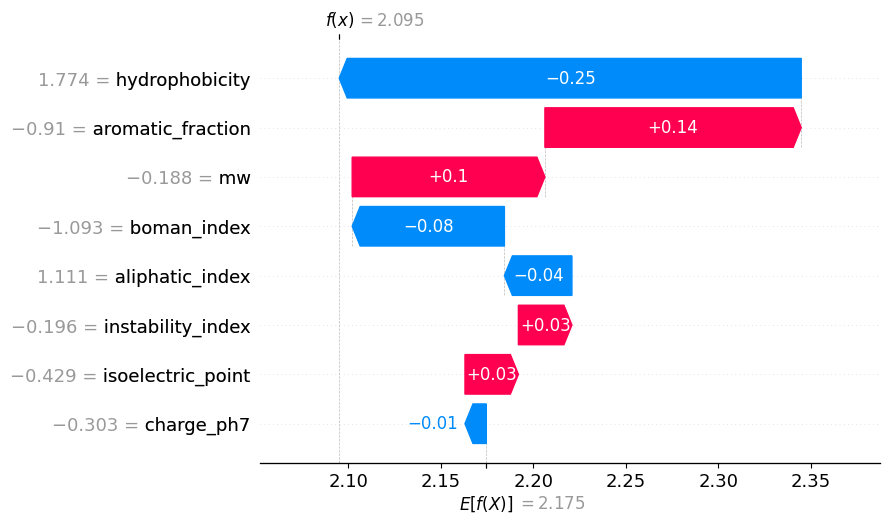


Peptide: NG (least potent, actual log(IC50)=4.08)


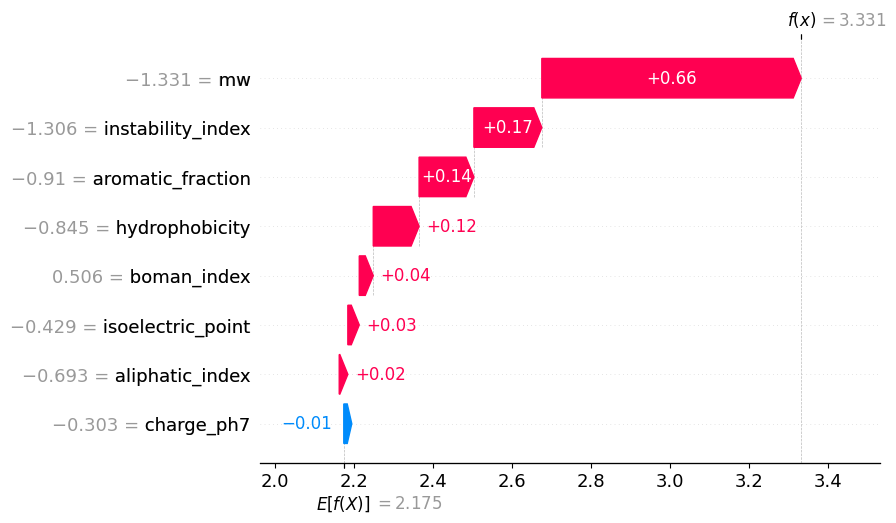

In [36]:
# A couple of individual-prediction explanations (most potent and least potent training examples)
most_potent_idx = y_train_d.idxmin()
least_potent_idx = y_train_d.idxmax()

for idx, label in [(most_potent_idx, "most potent"), (least_potent_idx, "least potent")]:
    pos = X_train_d.index.get_loc(idx)
    print(f"\nPeptide: {dipep.loc[idx, 'Sequence']} ({label}, actual log(IC50)={y_train_d.loc[idx]:.2f})")
    shap.plots.waterfall(shap_values[pos], show=True)


## 9. Stability selection

Fit a Lasso repeatedly on bootstrap resamples of the training set, and record how often
each descriptor gets a nonzero coefficient. A descriptor selected in most resamples is a
robust finding; one selected occasionally, by chance, on correlated features is not — this
directly addresses collinearity among the 8 descriptors (e.g. hydrophobicity-related
features are not fully independent of each other).


mw                   1.000
instability_index    0.855
hydrophobicity       0.795
aromatic_fraction    0.650
boman_index          0.520
aliphatic_index      0.395
charge_ph7           0.380
isoelectric_point    0.180
dtype: float64


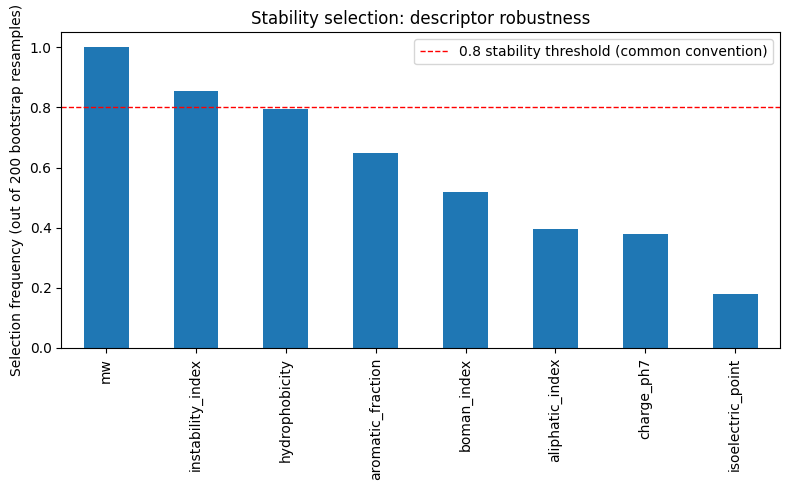

In [37]:
N_BOOTSTRAPS = 200
alpha_for_stability = 0.05  # keep fixed and modest; not re-tuned per resample on purpose

selection_counts = pd.Series(0, index=feature_cols_dipep)
rng = np.random.RandomState(RANDOM_STATE)

n_train = len(X_train_d)
for b in range(N_BOOTSTRAPS):
    idx = rng.choice(n_train, size=n_train, replace=True)
    Xb = X_train_d.iloc[idx]
    yb = y_train_d.iloc[idx]

    pipe = make_pipeline(StandardScaler(), Lasso(alpha=alpha_for_stability, max_iter=20000))
    pipe.fit(Xb, yb)
    coefs = pipe.named_steps["lasso"].coef_
    selection_counts += (np.abs(coefs) > 1e-8).astype(int)

selection_freq = (selection_counts / N_BOOTSTRAPS).sort_values(ascending=False)
print(selection_freq)

plt.figure(figsize=(8, 5))
selection_freq.plot(kind="bar")
plt.ylabel(f"Selection frequency (out of {N_BOOTSTRAPS} bootstrap resamples)")
plt.title("Stability selection: descriptor robustness")
plt.axhline(0.8, color="r", linestyle="--", linewidth=1, label="0.8 stability threshold (common convention)")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Limitations & write-up

**Scope:** primary model covers ACE-inhibitory dipeptides only (n=133). Peptides of
length ≥ 3 (n=595, ~82% of the compiled dataset) are reported as a diagnosed negative
result, not modeled further — see Section 6 for the evidence chain.

**Why dipeptides only, stated plainly:** a pooled model across all lengths looked
moderately promising on a single train/test split, but repeated CV showed most of that
signal collapses once dipeptides are excluded (Section 5). Reporting one pooled number
would have overstated where the model actually works.

**Sample size:** n=133 for the primary model is small; all CV estimates carry real
uncertainty (see reported ± std throughout) and should be read as such, not as precise
point estimates.

**Label quality:** at least 2 peptides sit at a suspiciously round, extreme value
(`log(IC50)=4.0`) consistent with an assay detection-limit / censoring convention rather
than a precise measurement (Section 3); this was flagged and monitored in residual
diagnostics (Section 7.4) rather than corrected, given project scope.

**Cross-study heterogeneity (untested):** the compiled dataset draws from many original
source studies with likely differing assay conditions; a `source_study` field would be
needed to test this directly as the ceiling on length ≥ 3 performance, and is not
available in the SI as provided.

**Interpretability caveat:** SHAP values and stability-selection frequencies describe
what this model relies on in this data — they are not, by themselves, evidence of
biological/mechanistic causality (Section 8).

**Generalization:** this model has not been tested outside the dipeptide chemical space
represented here (e.g. duckweed-derived or electromembrane-released peptides from a
different processing method) — any claim of transfer to a new peptide source is
untested and should be treated skeptically, consistent with the domain-shift issues
observed when applying external QSAR models in the reference literature.

**Data provenance:** raw compiled data (Wang et al. 2020 SI) not redistributed in this
repository per ACS's research-use SI policy; see top of notebook and README for the
official download source and citation.


## 11. Predicting a new peptide (demo)

A small utility to score a new dipeptide sequence with the final fitted pipeline —
useful for a "candidate prioritization" style demo, mirroring the internship's actual
end goal (ranking candidates, not just reporting a metric).


In [38]:
def predict_new_dipeptide(seq, model=final_model, feature_cols=feature_cols_dipep):
    if len(seq) != 2:
        raise ValueError("This model is scoped to dipeptides only (length=2).")
    desc = compute_descriptors(seq)
    X_new = pd.DataFrame([desc])[feature_cols]
    pred = model.predict(X_new)[0]
    return pred

for seq in ["FL", "PG", "VW"]:  # FL/VW known potent, PG known weak, from Section 3
    print(f"{seq}: predicted log(IC50) = {predict_new_dipeptide(seq):.3f}")


FL: predicted log(IC50) = 1.496
PG: predicted log(IC50) = 3.213
VW: predicted log(IC50) = 1.418
